In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [30]:
from sklearn.cluster import AgglomerativeClustering

# **Иерархическая кластеризация**

## **Теория**

**Процесс иерархической кластеризации:**

- Сравниваем точки, находим наиболее похожие друг на друга точки.
- Объединяем такие точки в кластеры.
- Сравниваем наиболее похожие друг на друга кластеры, объединяем кластеры.
- Повторяем шаги до тех пор, пока все точки не окажутся в одном кластере.

- Агломеративные методы (англ. agglomerative): новые кластеры создаются путем объединения более мелких кластеров и, таким образом, дерево создается от листьев к стволу;

- Дивизивные или дивизионные методы (англ. divisive): новые кластеры создаются путем деления более крупных кластеров на более мелкие и, таким образом, дерево создается от ствола к листьям.

**Дендрограмма** - древовидная схема с признаками

В иерархической кластеризации участвуют следующие компоненты:

1) Метрика "похожести" (Similarity Metric)
   Измеряет расстояние между двумя точками. Различные варианты:
   - Евклидово расстояние - по умолчанию
     
     $d(q, p)^2 = (p_1-q_1)^2 + (p_2 - q_2)^2$

     Каждый признак - отдельное измерение в пространстве признаков
     Для n точек и p признаков
     $D^2 = (x_11 - x_12)^2 + ... + (x_{n_1p_1} - x_{np})^2$
     
     Необходимо масштабирование данных! При MinMaxScaler max(расстояние)=1
   - Расстояние Манхэттена (расстояние городских кварталов)
   - Косинусное сходство и др.

2) Дендрограмма (Dendogram)
   по вертикали - расстояние между классами
   
   Разделять дерево для выбора количества классов
   

3) Матрица связей (Linkage Matrix)
   - Как измерить расстояние между точкой и целы кластером?
   - Как измерить расстояние между двумя кластерами?
         - между двумя самыми крайними точками двух кластеров
         - между двумя самыми дальними точками двух кластеров
         - найти расстояние между центрами кластеров
         - минимизировать расстояния между точками внутри кластера
     
   Критерий для определения того, как измерять расстояние межуд наборами точек

   Алгоритм объединяет пары кластеров так, чтобы минимизировать этот критерий

**Связи (Linkage)**

- **Ward**: минимизирует “variance” объединяемых кластеров.
- **Average**: использует среднее расстояние между двумя наборами точек.
- **Maximum (complete)**: максимальное расстояние между двумя наборами точек.
- **Minimum (single)**: минимальное расстояние между двумя наборами точек.

## **Код**

In [3]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\cluster_mpg.csv")
# про машины, Name - уникальный идентификатор, он не будет нужен для кластеризации

In [4]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [5]:
df.shape

(392, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 27.7+ KB


In [8]:
df.describe()
#смотрим масштабы признаков. Нужно масштабирование

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [9]:
df['origin'].value_counts()

origin
usa       245
japan      79
europe     68
Name: count, dtype: int64

In [10]:
df_with_dummies = pd.get_dummies(df.drop('name', axis=1))

In [11]:
df_with_dummies

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,False,False,True
...,...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790,15.6,82,False,False,True
388,44.0,4,97.0,52.0,2130,24.6,82,True,False,False
389,32.0,4,135.0,84.0,2295,11.6,82,False,False,True
390,28.0,4,120.0,79.0,2625,18.6,82,False,False,True


In [13]:
scaler = MinMaxScaler()

In [14]:
scaled_data = scaler.fit_transform(df_with_dummies)

In [16]:
#scaled_data

In [17]:
scaled_df = pd.DataFrame(scaled_data, columns=df_with_dummies.columns)

In [18]:
scaled_df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,0.239362,1.0,0.617571,0.456522,0.536150,0.238095,0.0,0.0,0.0,1.0
1,0.159574,1.0,0.728682,0.646739,0.589736,0.208333,0.0,0.0,0.0,1.0
2,0.239362,1.0,0.645995,0.565217,0.516870,0.178571,0.0,0.0,0.0,1.0
3,0.186170,1.0,0.609819,0.565217,0.516019,0.238095,0.0,0.0,0.0,1.0
4,0.212766,1.0,0.604651,0.510870,0.520556,0.148810,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
387,0.478723,0.2,0.186047,0.217391,0.333711,0.452381,1.0,0.0,0.0,1.0
388,0.930851,0.2,0.074935,0.032609,0.146583,0.988095,1.0,1.0,0.0,0.0
389,0.611702,0.2,0.173127,0.206522,0.193365,0.214286,1.0,0.0,0.0,1.0
390,0.505319,0.2,0.134367,0.179348,0.286929,0.630952,1.0,0.0,0.0,1.0


Каждая строка - отдельный автомобиль

В правой части только черные и белые цвета - там dummy-переменные либо 0, либо 1

Model year - градиент, т.к. в изначальном датафрейме по этой колонке была сортировка

<Axes: >

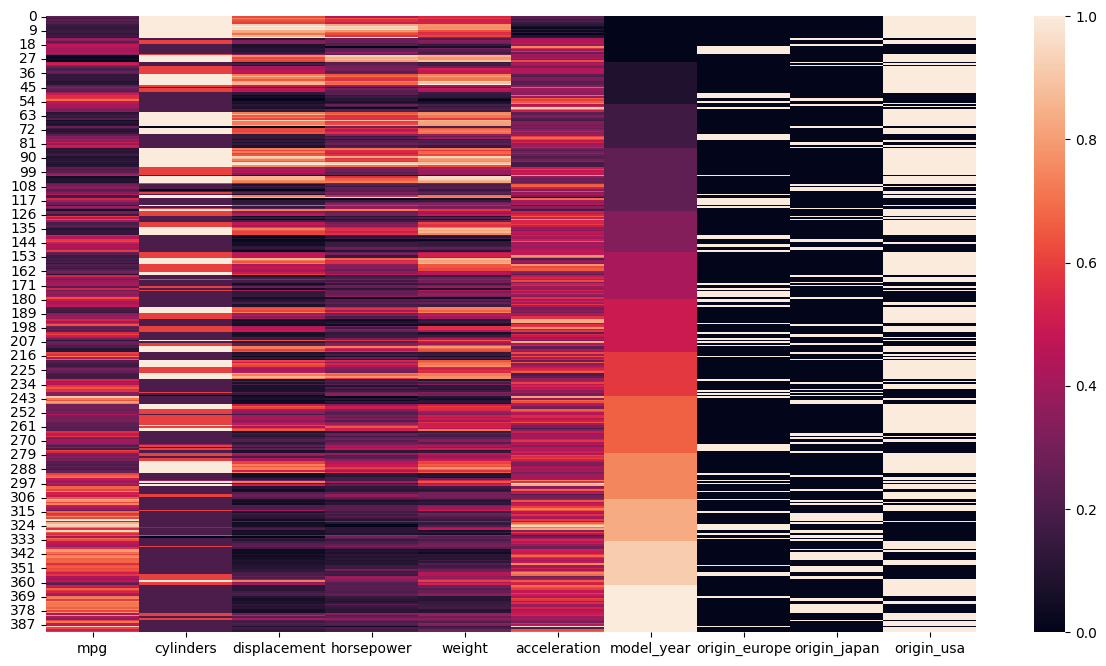

In [21]:
plt.figure(figsize=(15,8))
sns.heatmap(scaled_df)

seaborn делает кластеризацию и по строкам, и по столбцам (признакам). По столбцам помогает нам понять, какие признаки похожи между собойю Для этой же цели можно вычислить корреляцию

Высота линий - расстояние между точками/ кластерами

<Figure size 1500x800 with 0 Axes>

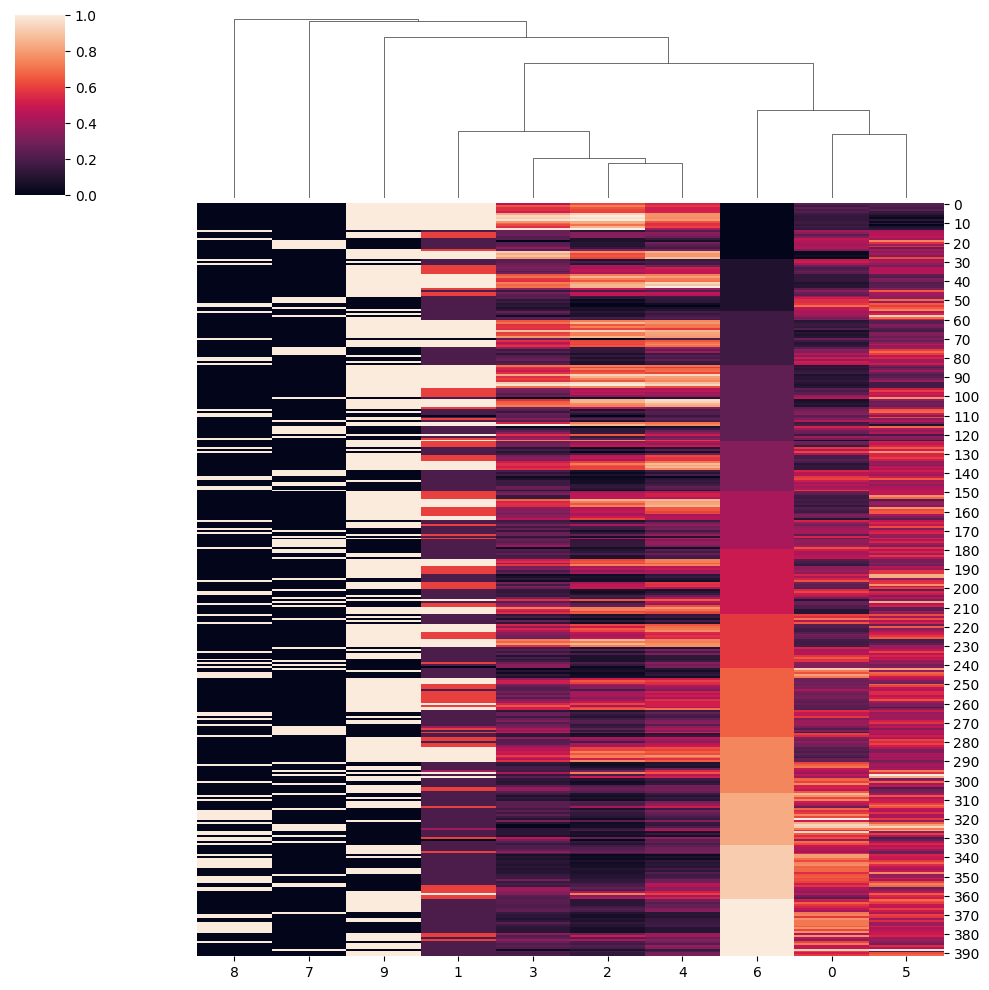

In [24]:
plt.figure(figsize=(15,8))
sns.clustermap(scaled_data, row_cluster=False)

<Axes: >

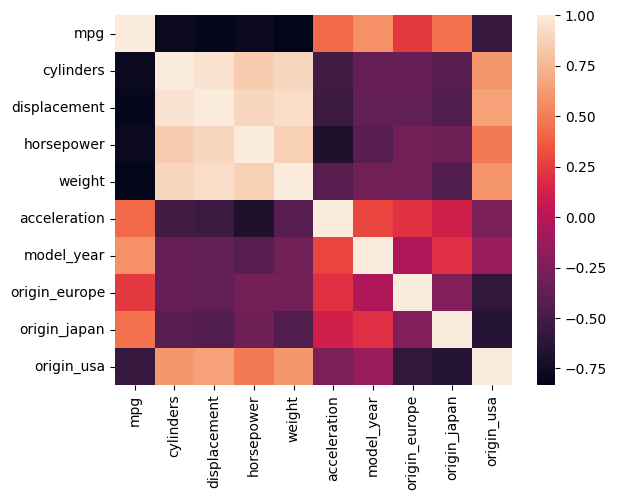

In [26]:
sns.heatmap(scaled_df.corr())

<Figure size 1500x800 with 0 Axes>

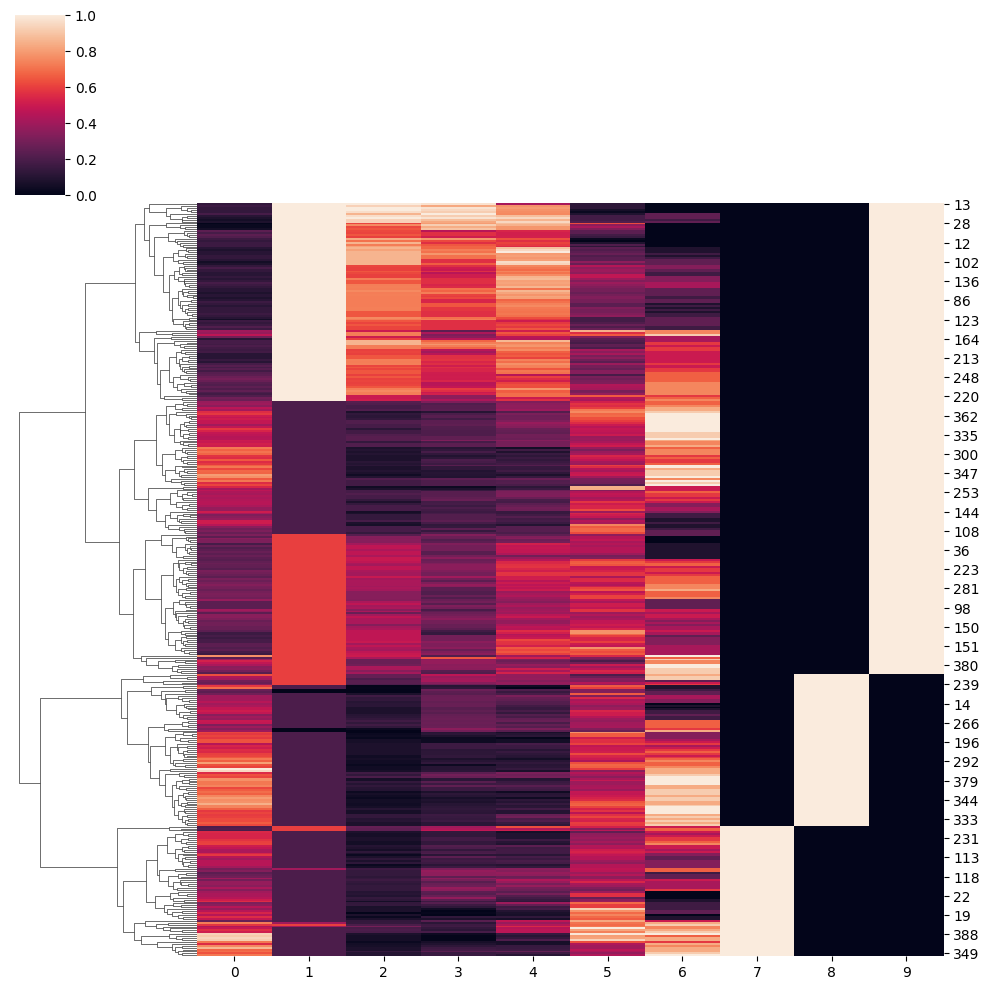

In [28]:
plt.figure(figsize=(15,8))
sns.clustermap(scaled_data, col_cluster=False)

In [32]:
model = AgglomerativeClustering(n_clusters=4)

In [34]:
#scaled_df

In [35]:
cluster_labels = model.fit_predict(scaled_df)

In [38]:
np.unique(cluster_labels)

array([0, 1, 2, 3])

<Axes: xlabel='mpg', ylabel='weight'>

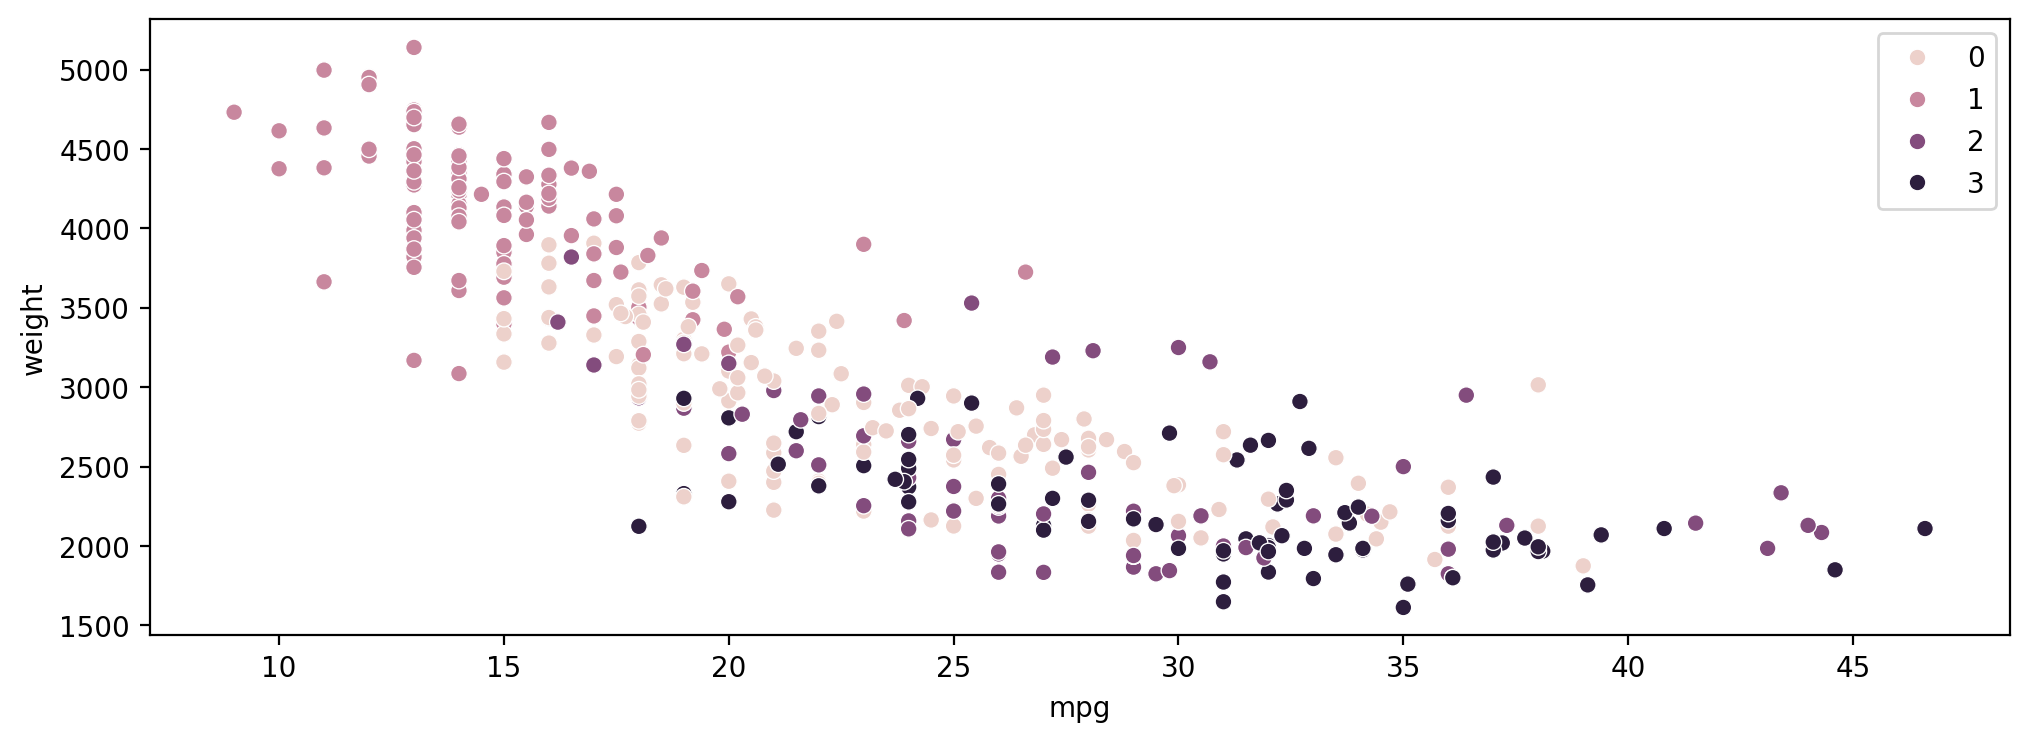

In [42]:
plt.figure(figsize=(12, 4),dpi=200)
sns.scatterplot(data=df, x='mpg', y='weight', hue=cluster_labels)

<Axes: xlabel='mpg', ylabel='horsepower'>

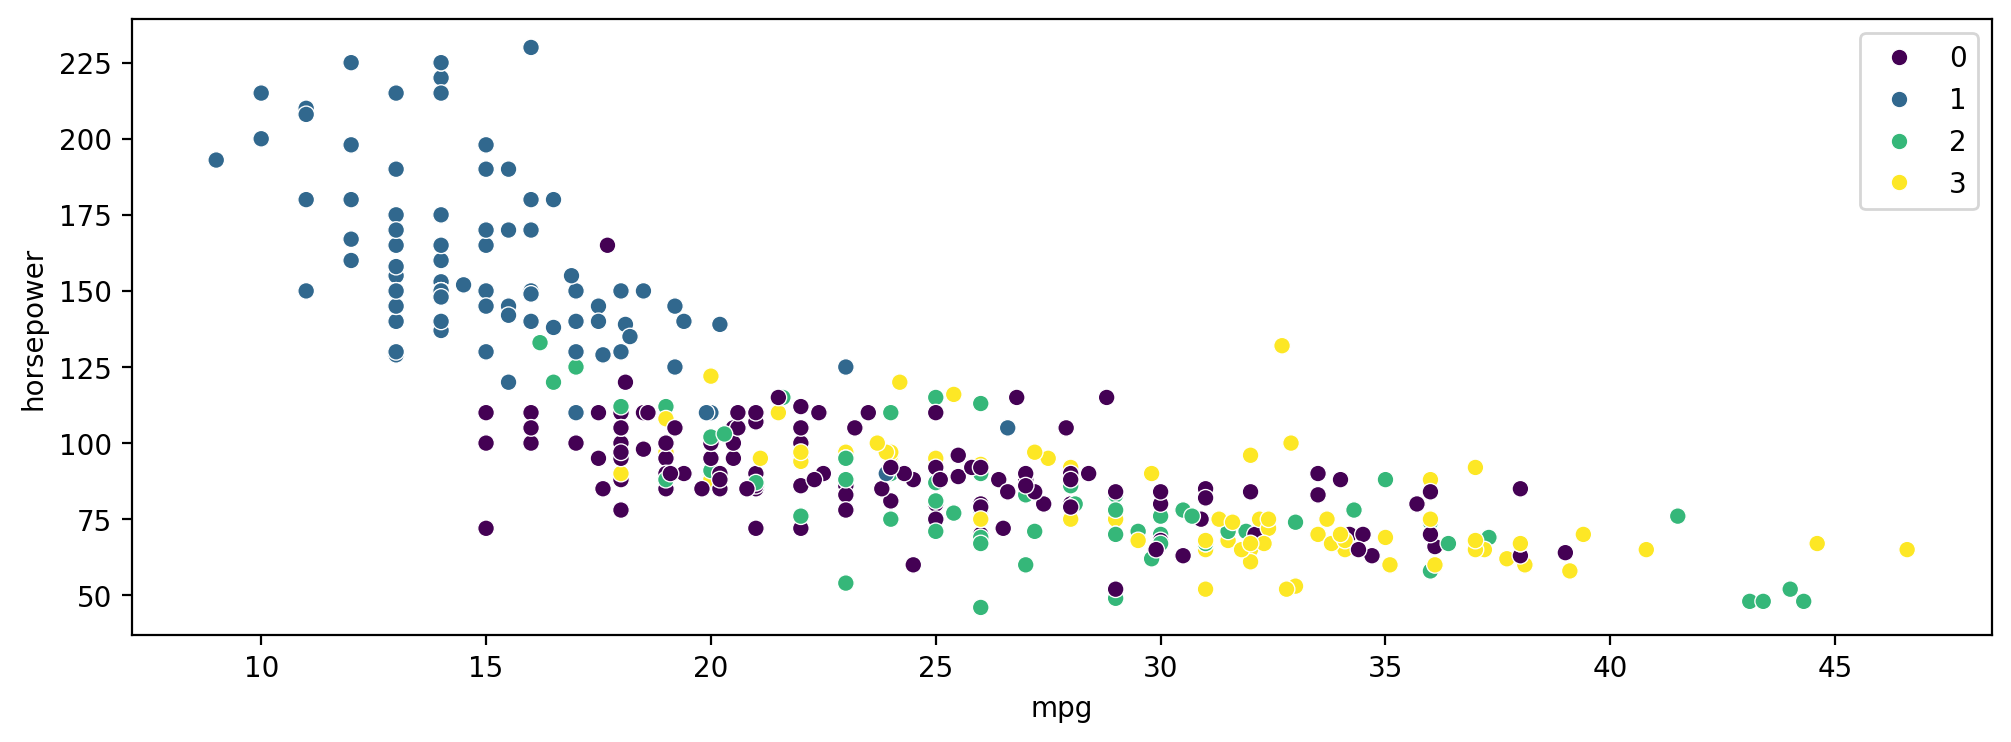

In [43]:
plt.figure(figsize=(12, 4),dpi=200)
sns.scatterplot(data=df, x='mpg', y='horsepower', hue=cluster_labels, palette='viridis')

Поменяем кол-во кластеров с 4 на 3

In [45]:
model_3 = AgglomerativeClustering(n_clusters=3)

In [49]:
cluster_labels_3 = model_3.fit_predict(scaled_df)

In [50]:
np.unique(cluster_labels_3)

array([0, 1, 2])

<Axes: xlabel='mpg', ylabel='weight'>

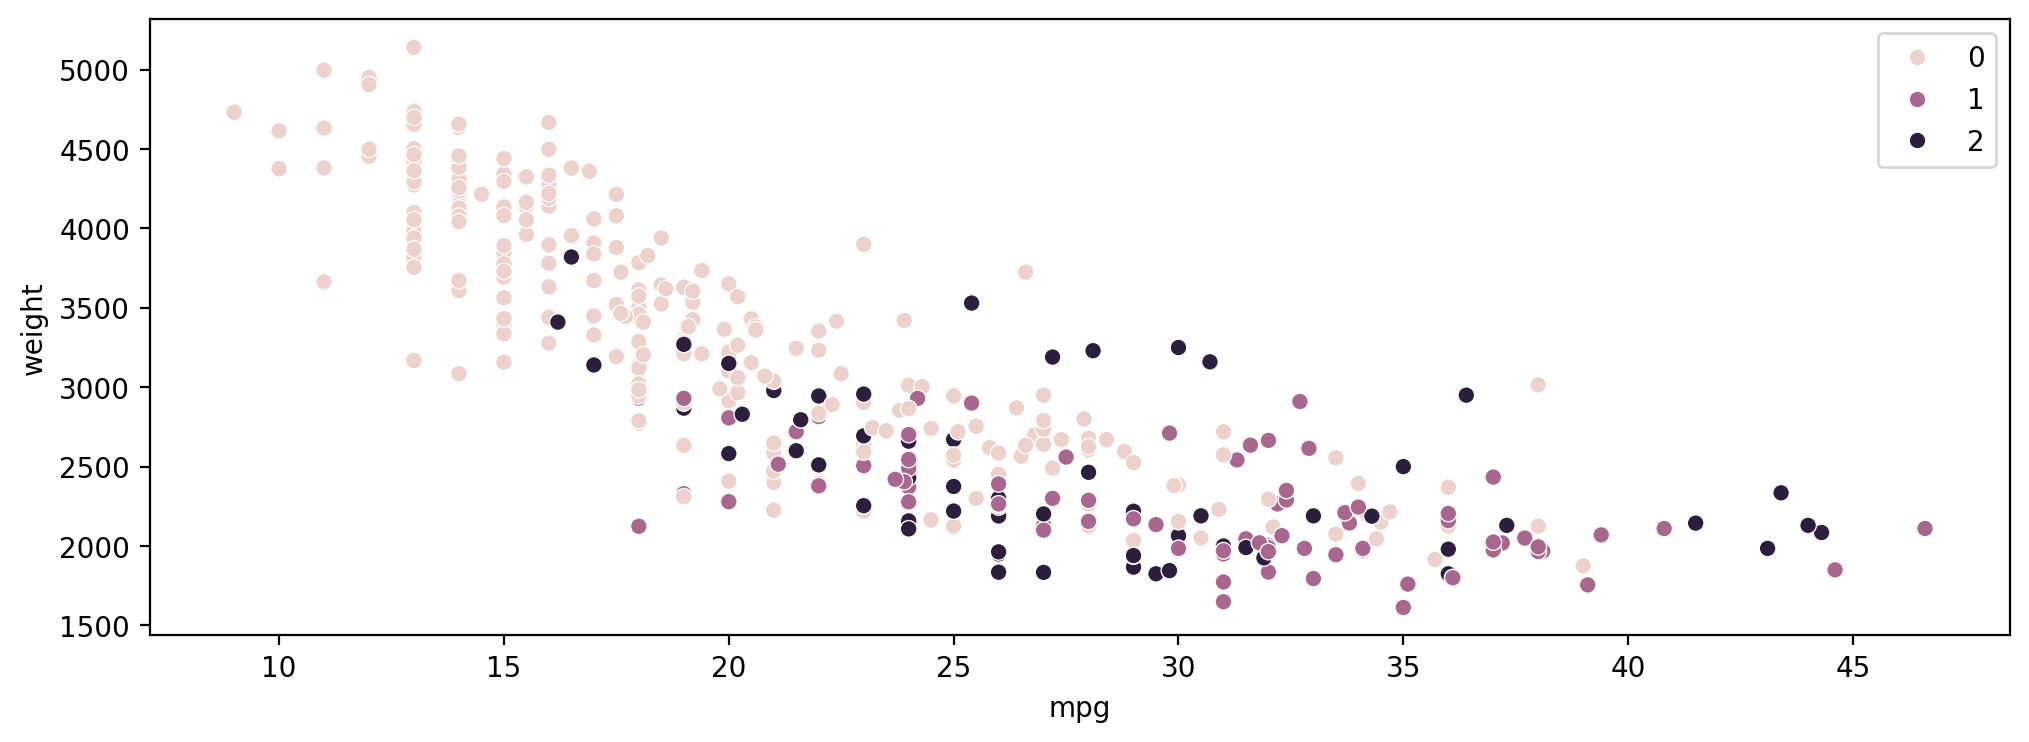

In [51]:
plt.figure(figsize=(12, 4),dpi=200)
sns.scatterplot(data=df, x='mpg', y='weight', hue=cluster_labels)

Дендограммы, и как с их помощью выбирать кол-во классов НЕ ЗАРАНЕЕ

**Максимальное расстояние между точками**

Из-pа MinMaxScaler максимальное значение = 1, минимальное = 0, и поэтому для евклидова расстояния каждое слагаемое <=1. 

Сумма же таких слагаемых <= количеству признаков N_features

Максимально возможное расстояние между 2 точками = $sqrt(N_{features})$

In [53]:
len(scaled_df.columns)

10

In [54]:
np.sqrt(10)

np.float64(3.1622776601683795)

Задаем ЛИБО кол-во кластеров, ЛИБО расстояние между кластерами

distance_threshold - расстояние, выше которого кластеры уже НЕ будут объединяться между собой

In [56]:
model_threshold = AgglomerativeClustering(n_clusters=None, distance_threshold=0)

distance_threshold=0: кол-во кластеров РАВНО количеству строк

In [60]:
model_threshold.fit_predict(scaled_df)

array([247, 252, 360, 302, 326, 381, 384, 338, 300, 279, 217, 311, 377,
       281, 232, 334, 272, 375, 354, 333, 317, 345, 329, 289, 305, 383,
       290, 205, 355, 269, 202, 144, 245, 297, 386, 358, 199, 337, 330,
       339, 293, 352, 283, 196, 253, 168, 378, 331, 201, 268, 256, 361,
       250, 197, 246, 371, 324, 230, 203, 261, 380, 376, 308, 389, 332,
       306, 236, 391, 350, 274, 288, 313, 231, 298, 100, 295, 210, 248,
       187, 390, 373, 266, 307, 379, 212, 357, 191, 314, 208, 249, 343,
       294, 374, 322, 323, 362, 188, 296, 369, 286, 251, 229, 244, 285,
       349, 365, 259, 213, 276, 215, 222, 204, 359, 287, 166, 387, 291,
       220, 216, 260, 129, 367, 340, 346, 301, 342, 228, 388, 370, 218,
       255, 327, 347, 278, 271, 258, 282, 318, 273, 123, 172, 382, 363,
       356, 195, 280, 239, 364, 267, 351, 186, 257, 277, 299, 127, 366,
       234, 385, 192, 372, 292, 233, 270, 263, 133, 165, 161, 198,  97,
       315, 134, 207, 147, 175, 262, 348,  98, 214,  48, 353, 17

In [61]:
from scipy.cluster.hierarchy import dendrogram

In [62]:
from scipy.cluster import hierarchy

In [63]:
linkage_matrix = hierarchy.linkage(scaled_df.values, method='ward')

In [ ]:
# method='ward' по умолчанию в AgglomerativeClustering

In [65]:
np.set_printoptions(suppress=True)

**дендограмма**

Первые две колонки - пара кластеров

Третья колонка - расстояние между ними

Четвертая - кол-во точек в двух кластерах

Снизу вверх растет

В самом конце кол-во 392 - общее кол-во точек

In [66]:
linkage_matrix

array([[ 67.        ,  68.        ,   0.0401977 ,   2.        ],
       [232.        , 234.        ,   0.0412867 ,   2.        ],
       [ 63.        ,  74.        ,   0.04316861,   2.        ],
       ...,
       [778.        , 779.        ,  10.74105893, 245.        ],
       [775.        , 777.        ,  12.18934549, 147.        ],
       [780.        , 781.        ,  19.30749251, 392.        ]],
      shape=(391, 4))

In [67]:
np.c_[model_threshold.children_, model_threshold.distances_]

array([[ 67.        ,  68.        ,   0.0401977 ],
       [232.        , 234.        ,   0.0412867 ],
       [ 63.        ,  74.        ,   0.04316861],
       ...,
       [778.        , 779.        ,  10.74105893],
       [775.        , 777.        ,  12.18934549],
       [780.        , 781.        ,  19.30749251]], shape=(391, 3))

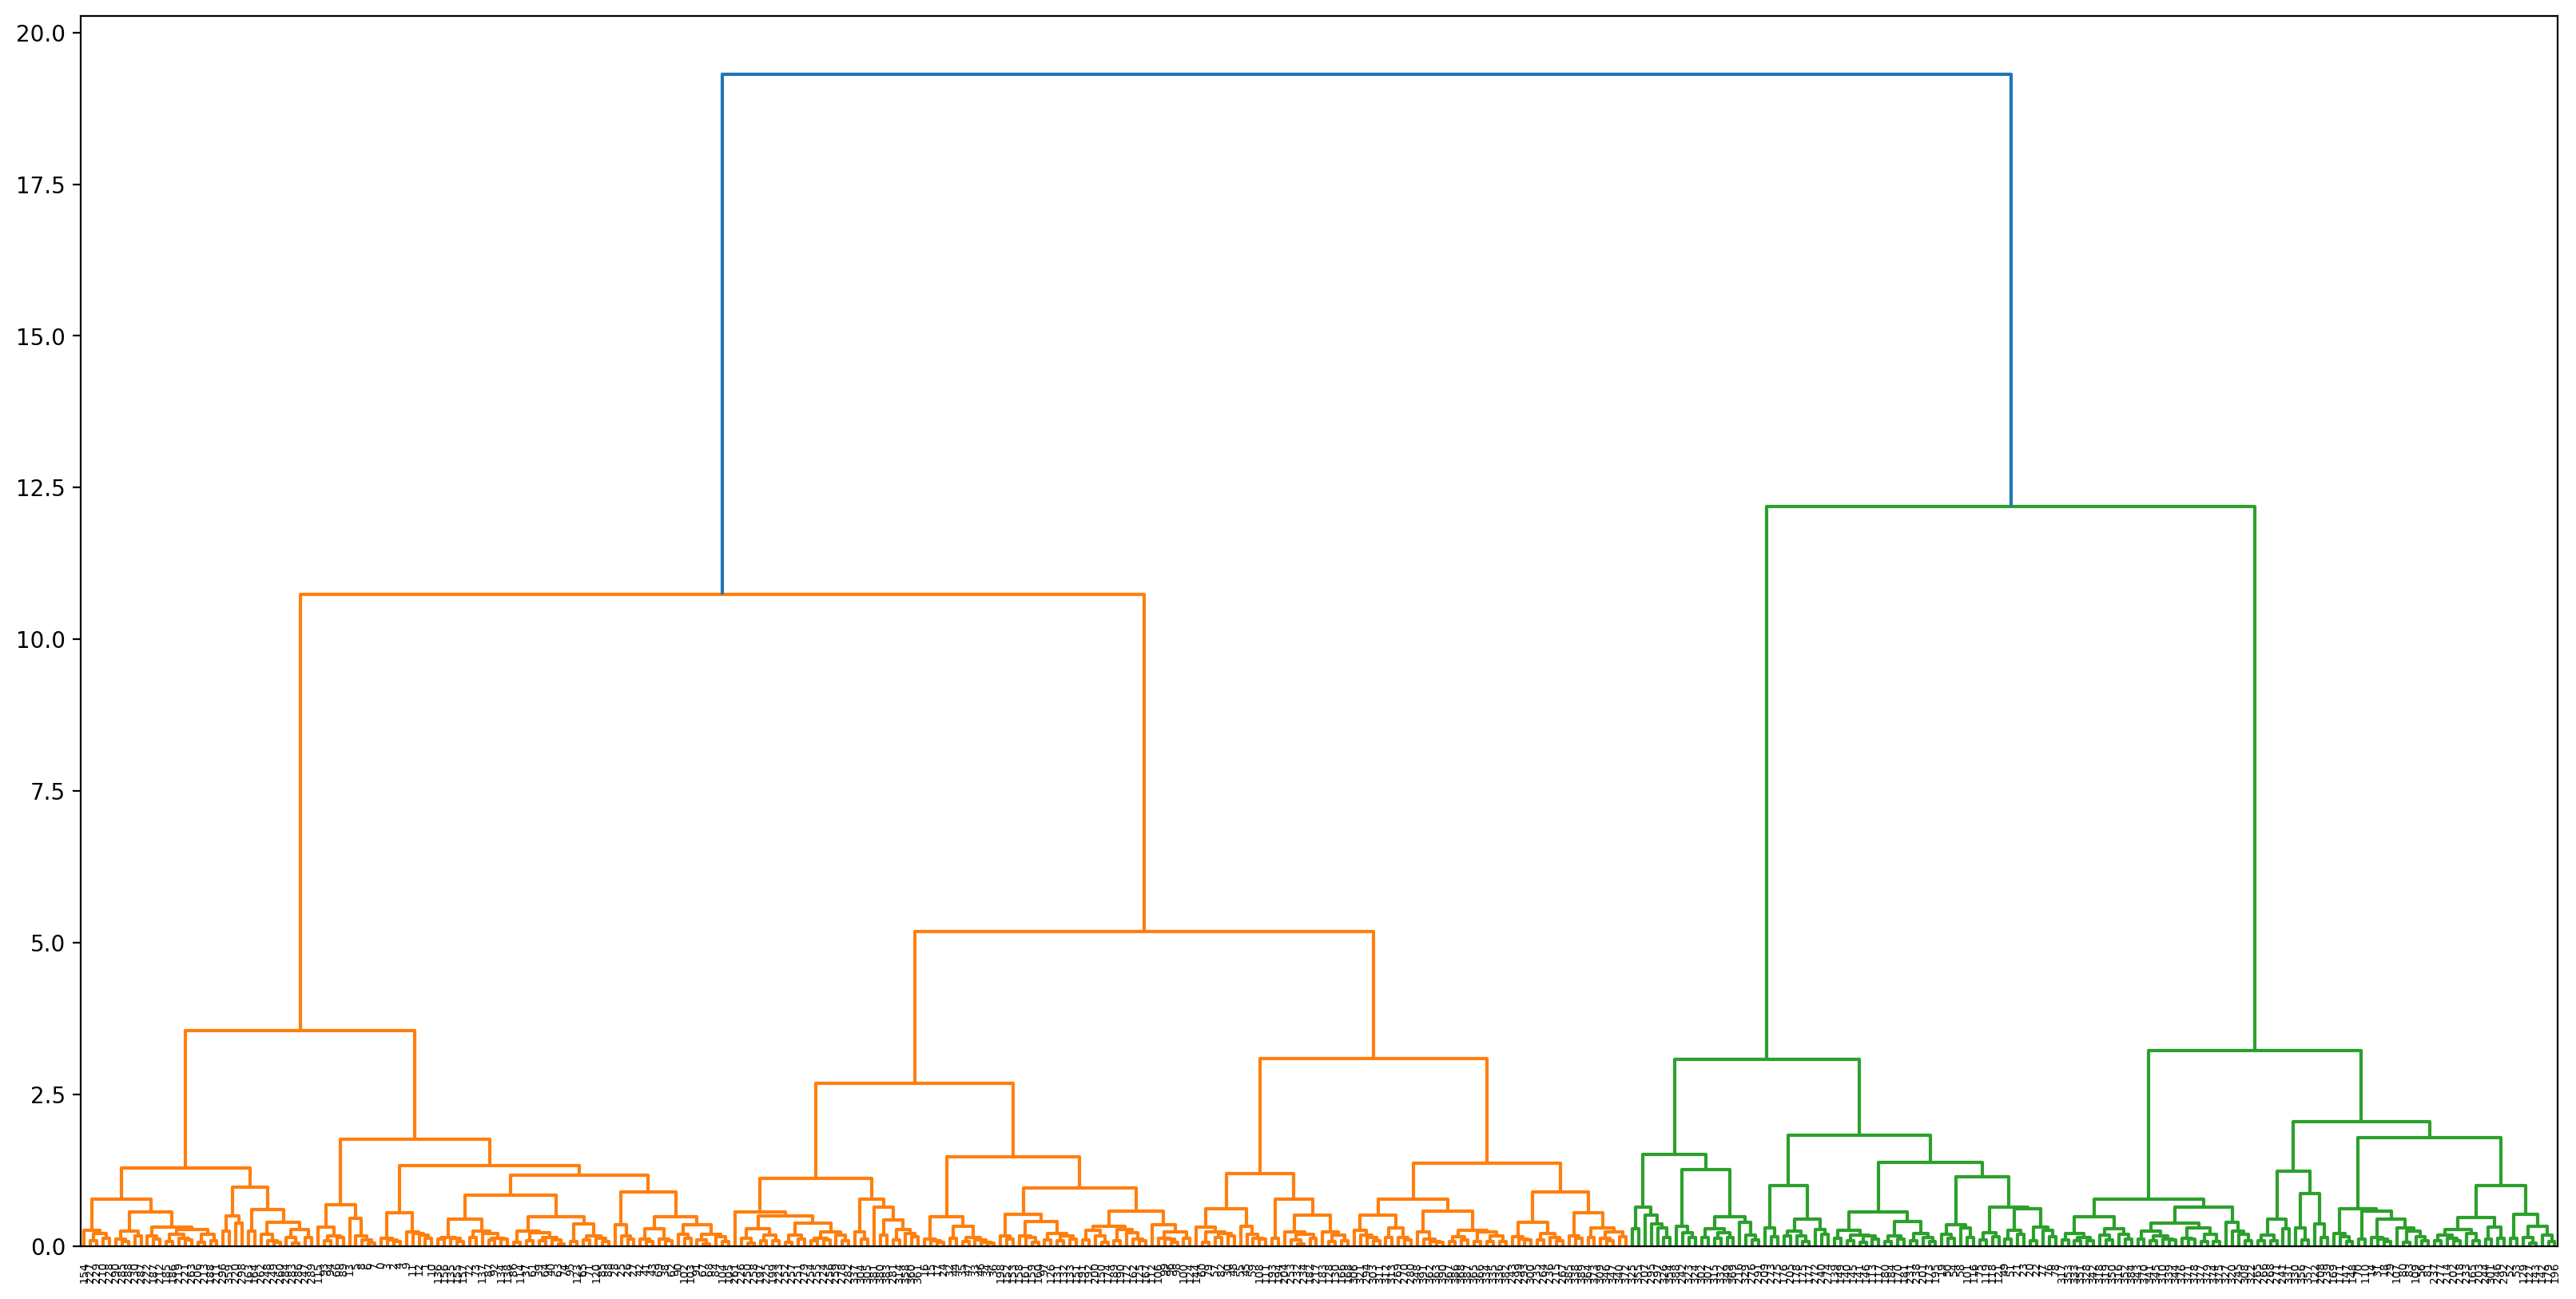

In [68]:
# plt.figure(figsize=(20, 10), dpi=200)
# dendro = dendrogram(linkage_matrix)

В какой-то момент построение дендрограммы можно остановить. 

За это отвечает параметр truncate_mode. 

Либо ограничиваем кол-во кластеров lastp , либо кол-во уровней level

Финальное объединение (верхнее) за уровень НЕ считается

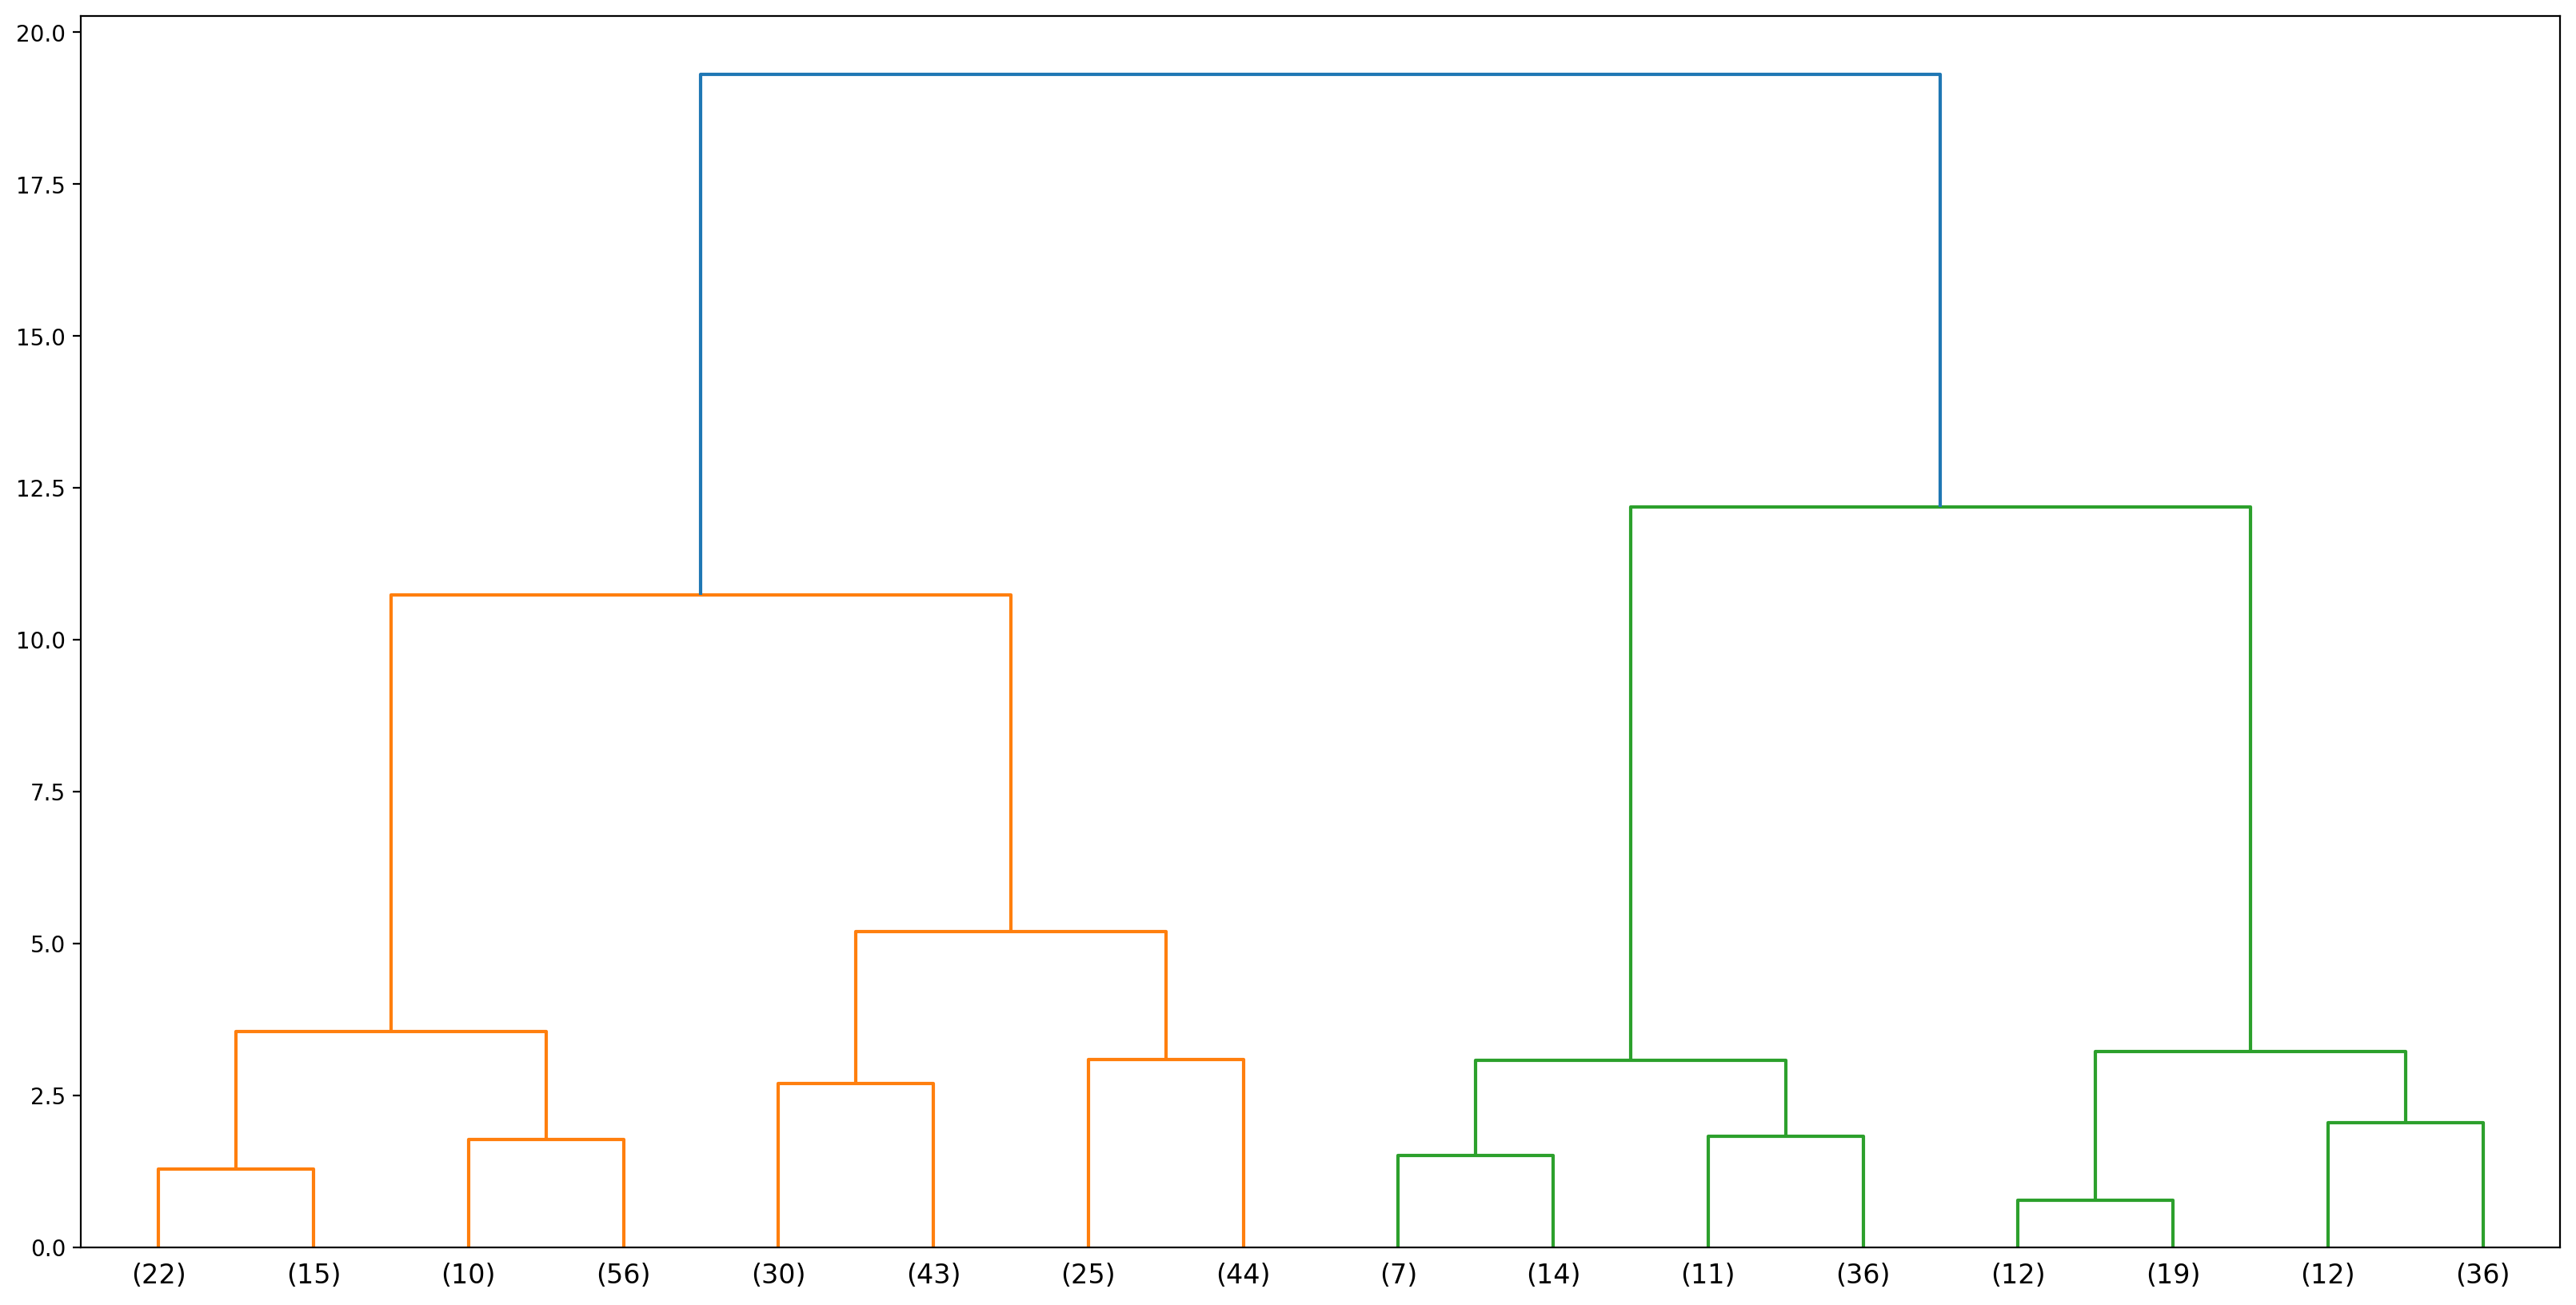

In [70]:
plt.figure(figsize=(20, 10), dpi=200)
dendro = dendrogram(linkage_matrix, truncate_mode='level', p=3)

In [71]:
scaled_df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,0.384200,0.494388,0.326646,0.317768,0.386897,0.448888,0.498299,0.173469,0.201531,0.625000
std,0.207580,0.341157,0.270398,0.209191,0.240829,0.164218,0.306978,0.379136,0.401656,0.484742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.212766,0.200000,0.095607,0.157609,0.173589,0.343750,0.250000,0.000000,0.000000,0.000000
50%,0.365691,0.200000,0.214470,0.258152,0.337539,0.446429,0.500000,0.000000,0.000000,1.000000
75%,0.531915,1.000000,0.536822,0.434783,0.567550,0.537202,0.750000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [72]:
np.sqrt(len(scaled_df.columns))

np.float64(3.1622776601683795)

In [73]:
scaled_df['mpg'].max()

np.float64(1.0000000000000002)

In [74]:
scaled_df['mpg'].idxmax()

320

In [75]:
scaled_df['mpg'].idxmin()

28

In [76]:
car_a = scaled_df.iloc[320]
car_b = scaled_df.iloc[28]

In [77]:
distance = np.linalg.norm(car_a - car_b)

In [78]:
distance

np.float64(2.3852929970374714)

Distance_threshold = 2

In [79]:
model_thresh_2 = AgglomerativeClustering(n_clusters=None, distance_threshold=2)

In [80]:
cluster_labels_thresh_2 = model_thresh_2.fit_predict(scaled_df)

In [81]:
cluster_labels_thresh_2 # 11 clusters

array([ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  1,  4,  4,
        4,  1,  0,  0,  0,  0,  0,  4,  3,  3,  3,  3,  1,  7,  1,  4,  4,
        4,  4,  4,  3,  3,  3,  3,  3,  3,  3,  4,  7,  4,  4,  7,  0,  0,
        0,  1,  1,  0,  7,  1,  7,  0,  7,  7,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  1,  3,  3,  3,  3,  0,  0,  0,  0,  7,  1,  1,  7,  1,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  0,
        3,  3,  3,  3,  4,  1,  7,  1,  1,  7,  4,  0,  3,  3,  0,  0,  0,
        0,  3,  0, 10,  3,  4,  4,  4,  1,  7,  1,  7,  4,  4,  4,  3,  3,
        3,  3,  3,  0,  0,  0,  1,  1,  7,  0,  0,  1,  1,  0,  4,  4,  4,
        4,  5,  3,  3,  3,  4,  4,  4,  4,  4,  5,  5,  1,  7,  4,  7,  1,
        0,  1,  4,  0,  4,  0,  0,  0,  0,  1,  0,  0,  7,  7,  0,  5,  5,
        5,  5,  4,  4,  4,  4,  7,  7,  0,  1,  9,  4,  9,  4,  0,  1,  1,
        7,  0,  5,  8, 10,  0,  5,  5,  5,  5,  1,  2,  8,  7,  1,  5,  5,
        5,  5,  9,  9,  9

In [82]:
linkage_matrix = hierarchy.linkage(scaled_df.values, method='ward')

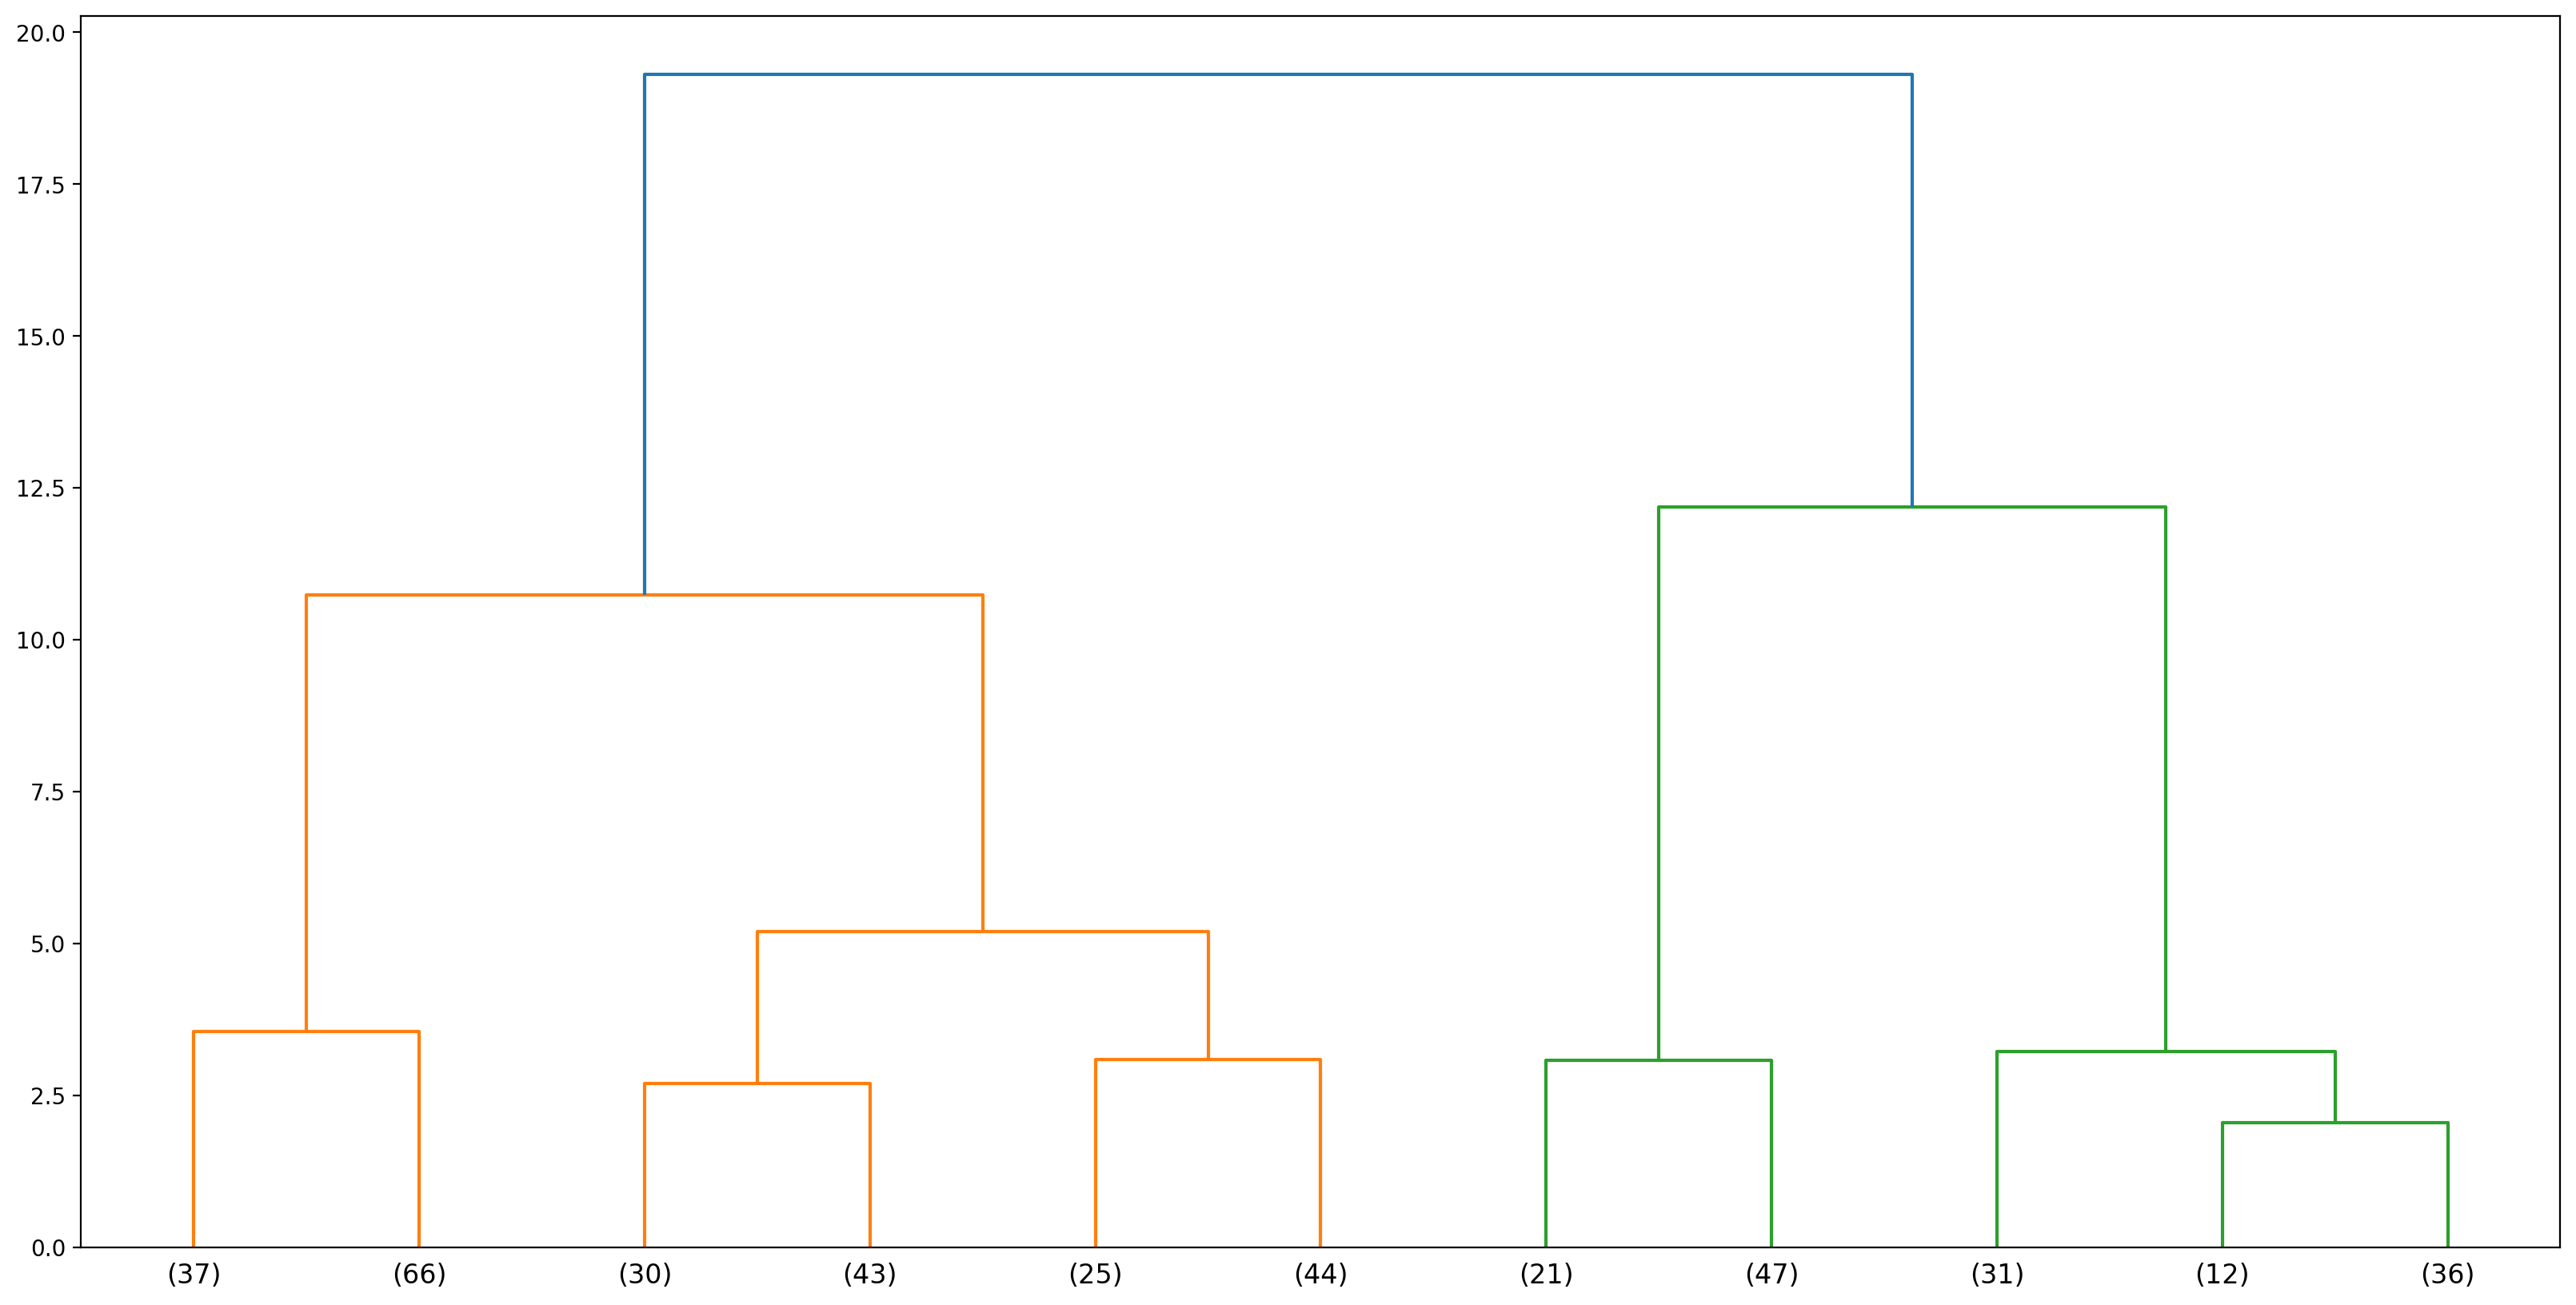

In [84]:
plt.figure(figsize=(20, 10), dpi=200)
dendro = dendrogram(linkage_matrix, truncate_mode='lastp', p=11)